#### **This script checks if there is any components in bi-partite graph**

In [1]:
import pandas as pd
import os

In [2]:
import networkx as nx

In [3]:
path = '/N/slate/potem/project/coordinationz/Outputs/Networks'

In [10]:
def files(campaign, path):
    return [f'{path}/{campaign}_tweets_courl_bipartiteEdges.csv',
            # f'{path}/{campaign}_tweets_coretweetusers_bipartiteEdges.csv',
            f'{path}/{campaign}_tweets_coretweet_bipartiteEdges.csv',
            f'{path}/{campaign}_tweets_cohashtag_bipartiteEdges.csv',
            f'{path}/{campaign}_tweets_coword_bipartiteEdges.csv'
           ]


def count_components(df):
    G = nx.from_pandas_edgelist(df, 'user', 'item')
    
    # Identify connected components
    components = list(nx.connected_components(G))
    
    # Optionally: get a set of all users (from the df column)
    user_set = set(df['user'].unique())
    
    # Count number of users in each component
    user_counts_per_component = [len([node for node in comp if node in user_set]) for comp in components]
    
    print("Number of users in each component:", user_counts_per_component)

    return user_counts_per_component, len(components)


In [11]:
campaigns = ['armenia_202012', #
            'bangladesh_201901_1', #
            'catalonia_201906_1', #
            'china_082019_1', #
            'china_082019_2', #
            'cuba_082020', #
            'ecuador_082019_1',
            'egypt_uae_082019_1',
            # 'ghana_nigeria_032020',
            'spain_082019_1', #
            'thailand_092020', #
            'uae_082019_1',
            'venezuela_201901_2',
            # 'venezuela_201906_1',
            # 'qatar_082020',
            # 'russia_201901_1',
            # 'iran_092020',
            # 'iran_201906_1',
            # 'iran_201906_2',
            # 'iran_201906_3',
            # 'iran_202012'
           ]

#Iran = 6 and Russia = 5

In [ ]:
all_result = []
for campaign in campaigns:
    # if campaign == 'thailand_092020':
    csv_files = files(campaign, path)
    for x in csv_files:
        indicators = x.split('tweets_')[1]
        indicator = indicators.split('_')[0]
        print(indicator)
        
        if os.path.exists(x) == False:
            print(x, ' Does not exists')
            all_result.append([campaign, indicator, [0], 0])
            continue
        
        print(f'\n\n  {campaign} \n\n', x)
        
        df = pd.read_csv(x)
        # print(df)

        num_components, count = count_components(df)

        all_result.append([campaign, indicator, num_components, count])
        
df_num = pd.DataFrame(data = all_result,
                      columns = ['campaign', 'indicator', 'size', 'num_components']
                     )

In [17]:
import matplotlib.pyplot as plt
import matplotlib.colors as pltc

def bar_graph(parameters):
    '''
    Plots the bar graph
    '''
    
    # parameters =  {
    #     'fontsize': 14,
    #     'size': (10, 12),
    #     'bar': 'h',
    #     'x': x,
    #     'y': y,
    #     'xlabel': 'Number of targets (Egypt_022020 campaign)', 
    #     'ylabel': 'Countries',
    #     'legend_location': '',
    #     # 'labelrotation': 90,
    #     # 'title': 'Egypt_022020',
    #     'save': {
    #         'path': reply_plot_path,
    #         'filename': 'egypt_022020_target_country.png'
    #     },
    #     'random_color': False
    # }
    
    keys = parameters.keys()
    
    if 'size' in keys:
        size = parameters['size']
    else:
        size = (8, 8)
        
    
    fig, ax = plt.subplots(figsize=size)
        
    fontsize = parameters['fontsize']
    colors = ['red', 'blue', 'orange', 'red', 'olive', 
              'pink', 'lime', 'maroon']
    
    x = parameters['x']
    y = parameters['y']
    
    if ('bar' in keys) and parameters['bar'] == 'h':
        print('here')
        ax.barh(y,
               x, 
               alpha=0.5,
               color=colors[1],
                )
    else:
        ax.bar(x,
           y, 
           alpha=0.5,
           color=colors[1],
            )
        
    ax.set_ylabel(parameters['ylabel'], fontsize=fontsize)
    ax.set_xlabel(parameters['xlabel'], fontsize=fontsize)

    if 'tick_size' in keys:
        tick_size = parameters['tick_size']
    else:
        tick_size = fontsize
        
    ax.tick_params(axis='both', 
                   which='both', 
                   labelsize=tick_size, 
                   labelbottom=True)
    
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelbottom=True)
    
    #######################

    if 'legend_location' in keys:
        if 'legend_font' in keys:
            legend_font = parameters['legend_font']
        else:
            legend_font = fontsize
            
        ax.legend(loc=parameters['legend_location'], 
                  frameon=True, 
                  fontsize=legend_font
                 )
        
    if 'legend_lower' in keys:
        box = ax.get_position()
        ax.set_position([box.x0, box.y0 + box.height * 0.1,
                         box.width, box.height * 0.9])

        # Put a legend below current axis
        ax.legend(loc='upper center', 
                  bbox_to_anchor=(1, -0.06),
                  fancybox=True, 
                  shadow=True, ncol=3)
    
    
        # ax.xaxis.set_minor_locator(AutoMinorLocator())

    if 'figure_text' in keys:
        plt.text(parameters['figure_text_x'], 
                 parameters['figure_text_y'], 
                 parameters['figure_text'], 
                 fontsize=parameters['figure_font'],
                 ha="center", 
                 va="center", 
                )
        
    
    #######################

    if ('bar' in keys) and parameters['bar'] == 'h':
        max_value = max(x)
        plt.xticks(np.arange(0, max_value + 5, 5))
        
    if 'title' in keys:
        title = parameters['title']
        ax.set_title(f'{title}')

    if ('labelrotation' in keys) and parameters['labelrotation'] != None:
        labelrotation = parameters['labelrotation']
    else:
        labelrotation = None
        
    if ('bar' in keys) and parameters['bar'] == 'h':
        ax.set_yticklabels(ax.get_yticklabels(), rotation=labelrotation)
    else:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=labelrotation)
    
    fig.tight_layout()

    if 'show' in keys and parameters['show'] == False:
        plt.close()
    else:
        plt.show()
    
    if 'save' in keys:
        save_path = parameters['save']['path']
        filename = parameters['save']['filename']

        fig.savefig(f'{save_path}/{filename}', 
              facecolor='white', 
              transparent=False)
        

In [18]:
df_num.columns

Index(['campaign', 'indicator', 'size', 'num_components'], dtype='object')

               campaign indicator  num_components
0        armenia_202012     courl               0
4   bangladesh_201901_1     courl               0
8    catalonia_201906_1     courl               0
12       china_082019_1     courl               4
16       china_082019_2     courl               1
20          cuba_082020     courl               7
24     ecuador_082019_1     courl               2
28   egypt_uae_082019_1     courl               0
32       spain_082019_1     courl               1
36      thailand_092020     courl               0
40         uae_082019_1     courl               3
44   venezuela_201901_2     courl               1


/tmp/ipykernel_303804/1141905546.py:129: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=labelrotation)


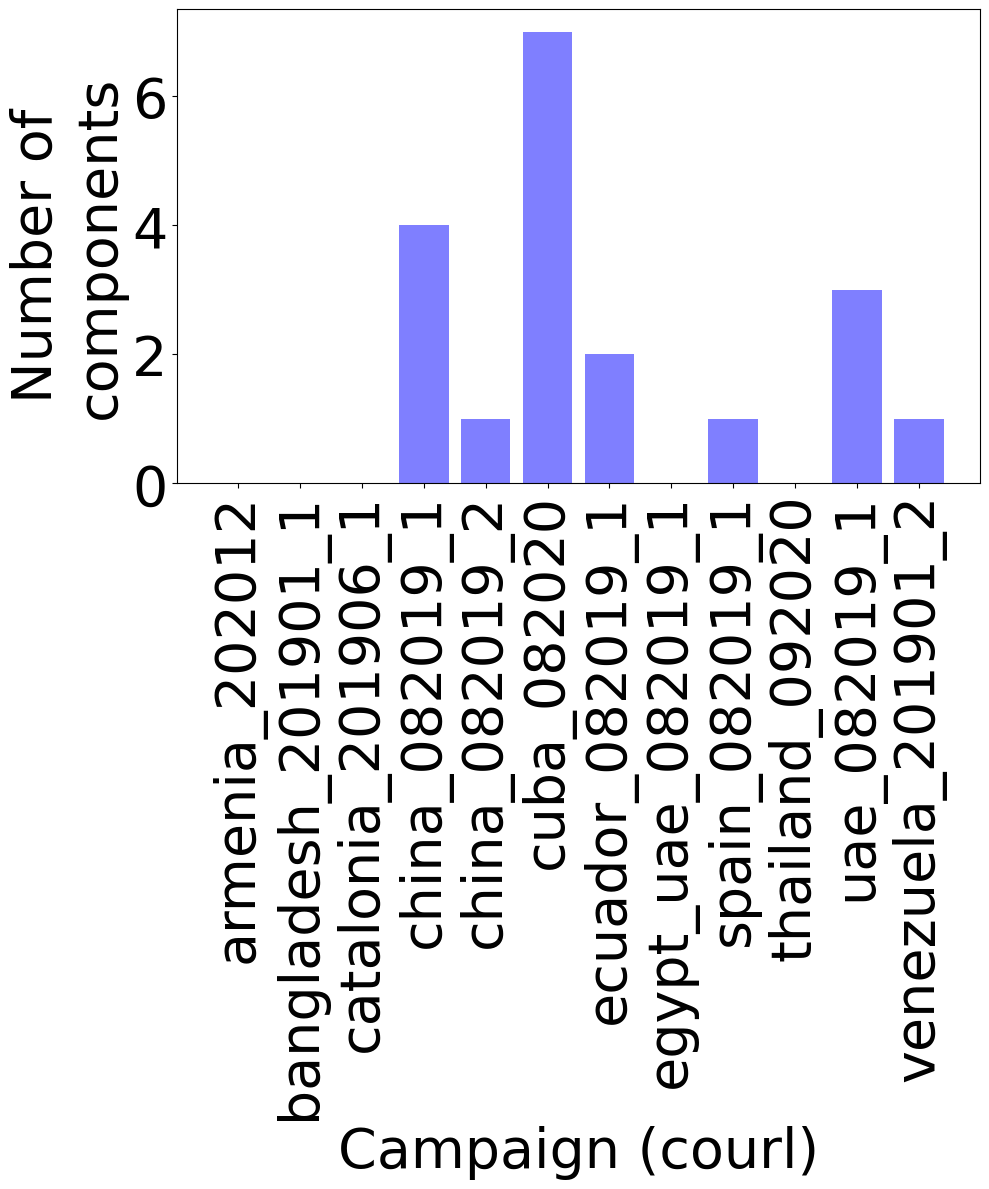

               campaign  indicator  num_components
1        armenia_202012  coretweet               1
5   bangladesh_201901_1  coretweet               0
9    catalonia_201906_1  coretweet               0
13       china_082019_1  coretweet               7
17       china_082019_2  coretweet               0
21          cuba_082020  coretweet               4
25     ecuador_082019_1  coretweet               2
29   egypt_uae_082019_1  coretweet               1
33       spain_082019_1  coretweet               1
37      thailand_092020  coretweet               3
41         uae_082019_1  coretweet               7
45   venezuela_201901_2  coretweet               4


/tmp/ipykernel_303804/1141905546.py:129: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=labelrotation)


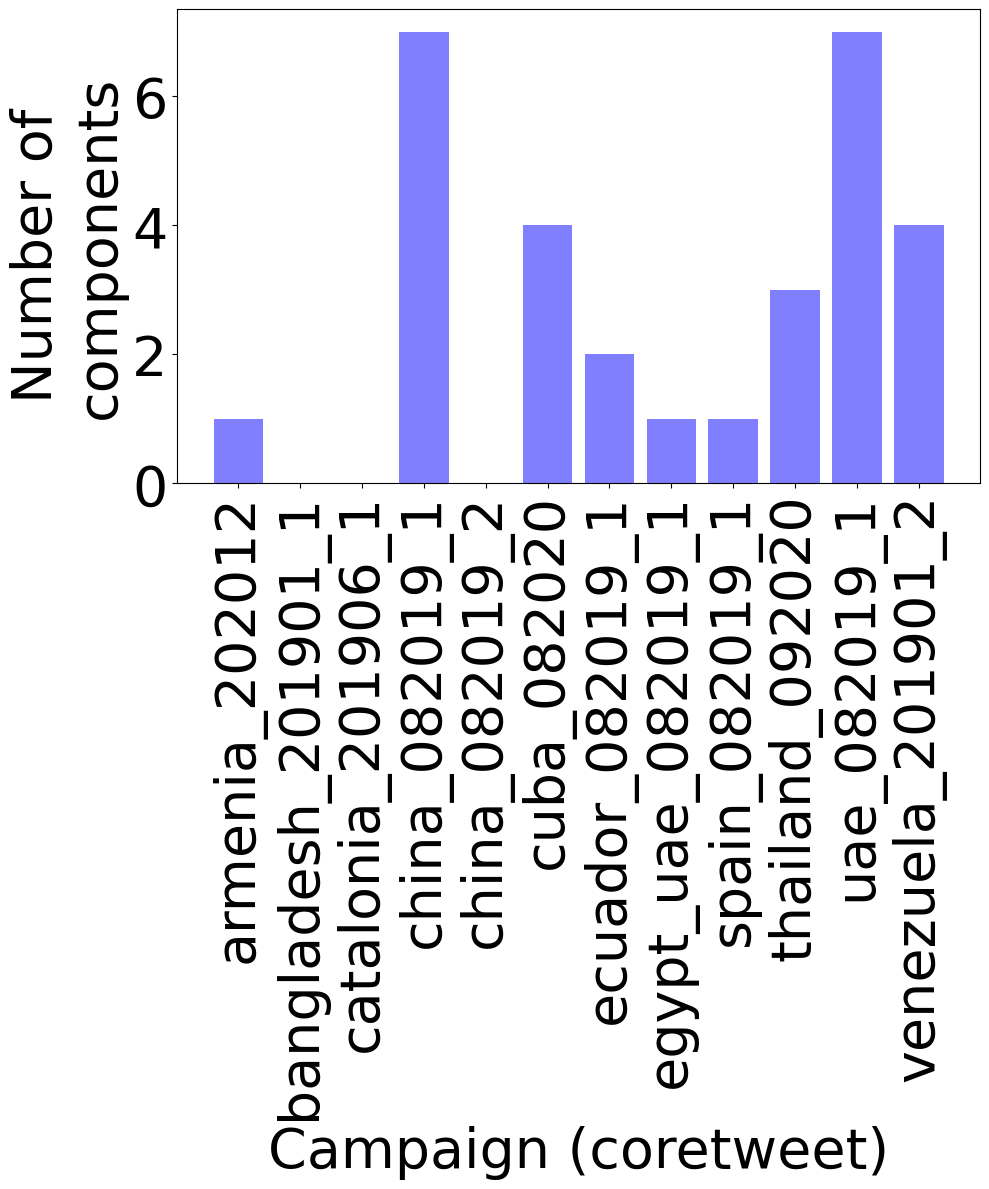

               campaign  indicator  num_components
2        armenia_202012  cohashtag               1
6   bangladesh_201901_1  cohashtag               1
10   catalonia_201906_1  cohashtag               0
14       china_082019_1  cohashtag               1
18       china_082019_2  cohashtag               1
22          cuba_082020  cohashtag               1
26     ecuador_082019_1  cohashtag               1
30   egypt_uae_082019_1  cohashtag               1
34       spain_082019_1  cohashtag               1
38      thailand_092020  cohashtag               0
42         uae_082019_1  cohashtag               1
46   venezuela_201901_2  cohashtag               1


/tmp/ipykernel_303804/1141905546.py:129: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=labelrotation)


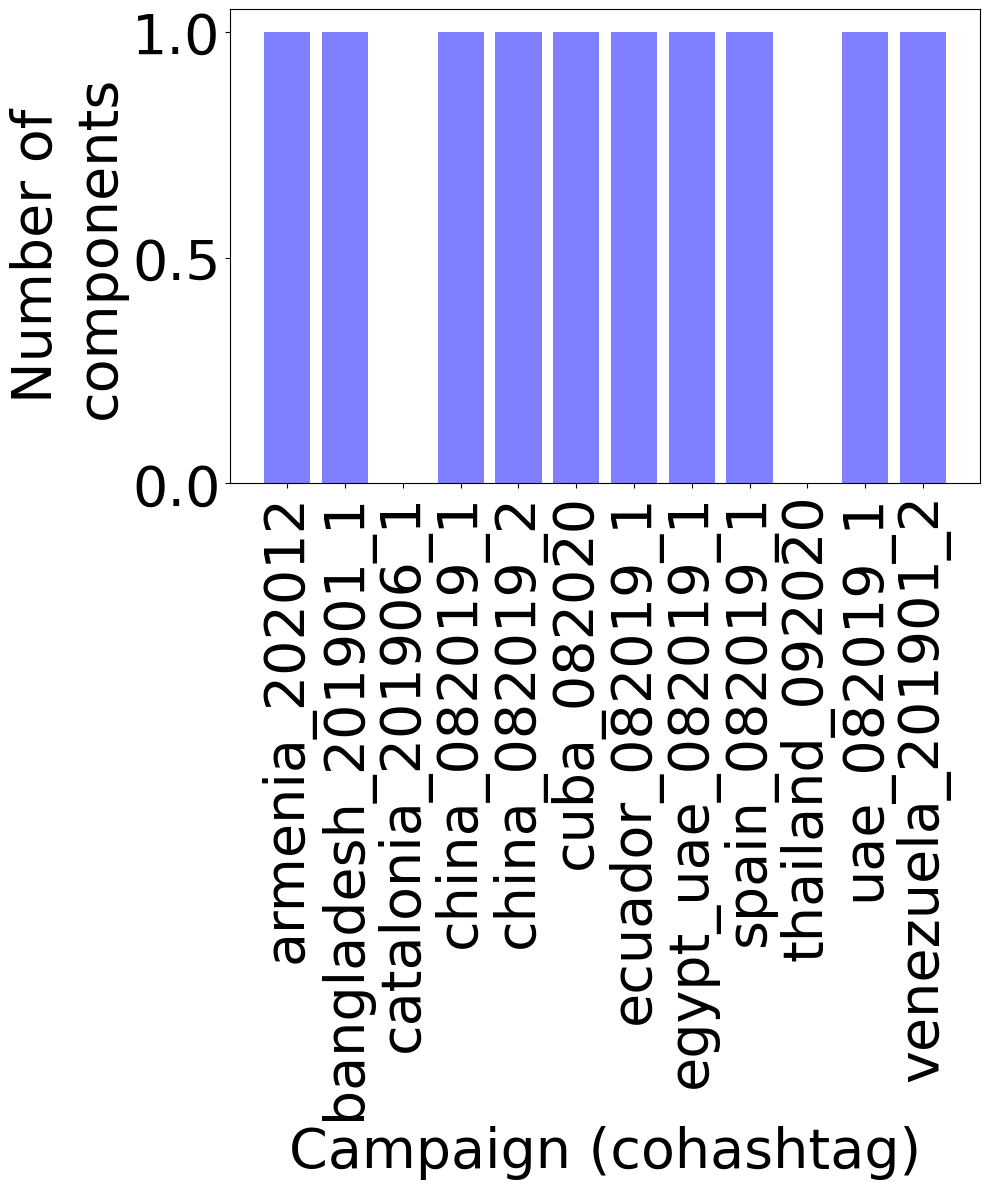

               campaign indicator  num_components
3        armenia_202012    coword               1
7   bangladesh_201901_1    coword               1
11   catalonia_201906_1    coword               1
15       china_082019_1    coword               1
19       china_082019_2    coword               1
23          cuba_082020    coword               1
27     ecuador_082019_1    coword               1
31   egypt_uae_082019_1    coword               1
35       spain_082019_1    coword               1
39      thailand_092020    coword               1
43         uae_082019_1    coword               1
47   venezuela_201901_2    coword               1


/tmp/ipykernel_303804/1141905546.py:129: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=labelrotation)


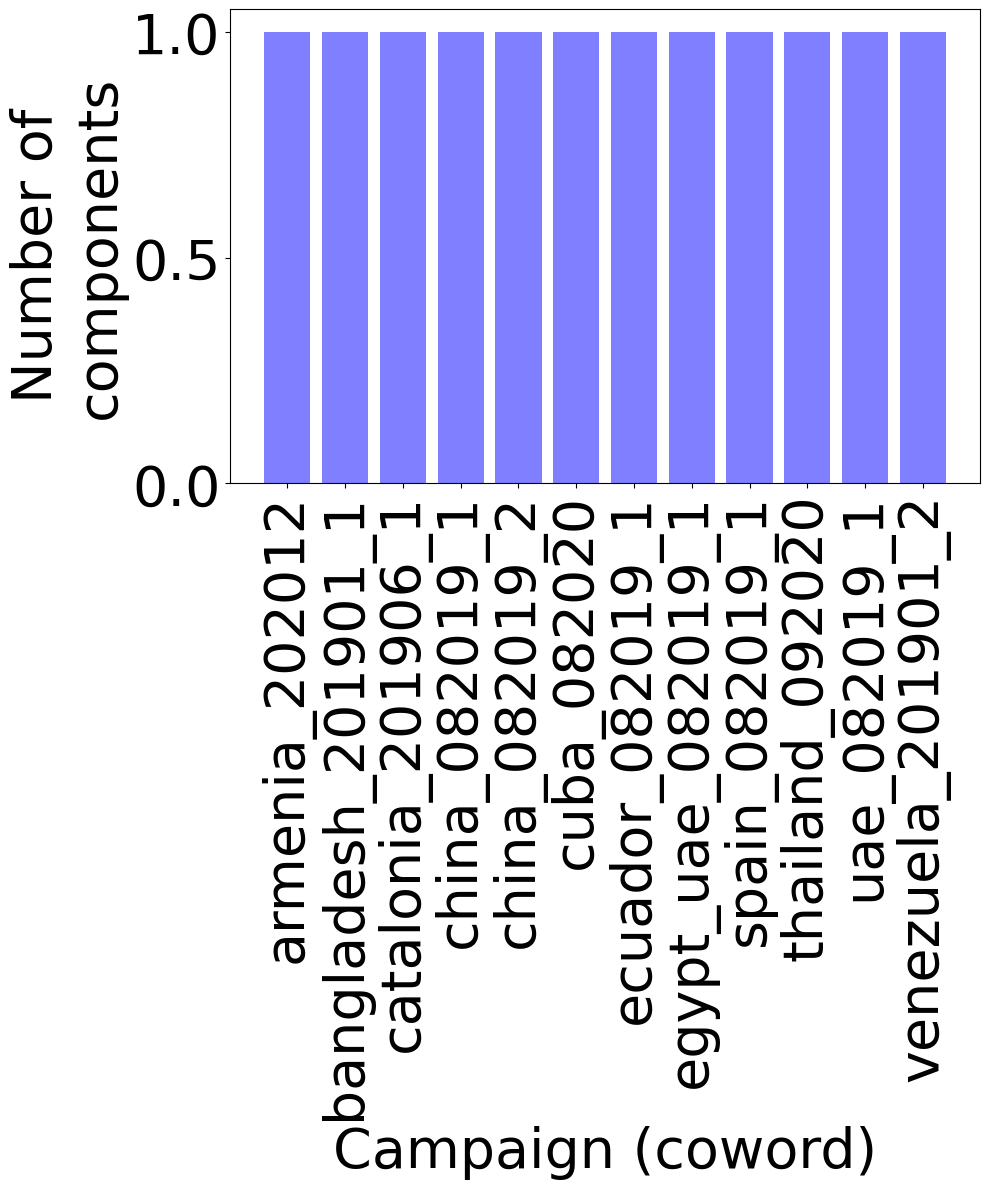

In [15]:
for x in df_num['indicator'].unique():
    df_x = df_num.loc[df_num['indicator'] == x]
    print(df_x)
    parameters =  {
            'fontsize': 40,
            'size': (10, 12),
            # 'bar': 'h',
            'x': df_x['campaign'],
            'y': df_x['num_components'],
            'xlabel': f'Campaign ({x})', 
            'ylabel': 'Number of \ncomponents',
            'labelrotation': 90,
            'save': {
                'path': './plots',
                'filename': f'{x}_bar_graph_component.png'
            },
            'random_color': False
        }
    
    bar_graph(parameters)

#### **Size of each component**

In [20]:
df_num.head()

,campaign,indicator,size,num_components
0,armenia_202012,courl,0,0
1,armenia_202012,coretweet,[12],1
2,armenia_202012,cohashtag,[72],1
3,armenia_202012,coword,[752],1
4,bangladesh_201901_1,courl,0,0


In [67]:
def scatterplot(parameters):
    if 'size' in parameters:
        size = parameters['size']
    else:
        size=(10,10)
        
    keys = parameters.keys()
    fig, ax = plt.subplots(figsize=size)
    fontsize = parameters['fontsize']
    
    if 'h' in keys and parameters['h'] == True:
        h = False
    else:
        h = True
        
    ax.scatter(parameters['x'], parameters['y'], c='blue')
    
    if 'log_yscale' in keys and parameters['log_yscale'] == True:
        ax.set_yscale('log')
    if 'log_xscale' in keys and parameters['log_xscale'] == True:
        ax.set_xscale('log')
    
    if 'tick_size' in keys:
        tick_size = parameters['tick_size']
    else:
        tick_size = fontsize
    
    ax.tick_params(axis='both', 
                   which='major', 
                   labelsize=tick_size
                  )
    

    ax.set_xlabel(parameters['xlabel'], 
                  fontsize=fontsize)
    ax.set_ylabel(parameters['ylabel'], 
                  fontsize=fontsize)
    if ('labelrotation' in keys) and parameters['labelrotation'] != None:
        labelrotation = parameters['labelrotation']
    else:
        labelrotation = None
        
    ax.tick_params(axis='x', labelrotation=labelrotation)
    
    if 'title' in parameters:
        title = parameters['title']
        ax.set_title(f'{title}')
    
    fig.tight_layout()
    
    if 'save' in keys:
        path = parameters['save']['path']
        filename = parameters['save']['filename']
        
        fig.savefig(f'{path}/{filename}', 
              facecolor='white', 
              transparent=False)
        
    plt.show()
    

In [33]:
df_expanded = df_num.explode('size', ignore_index=True)

In [47]:
# df_expanded

In [45]:
len(df_x['campaign'])

24

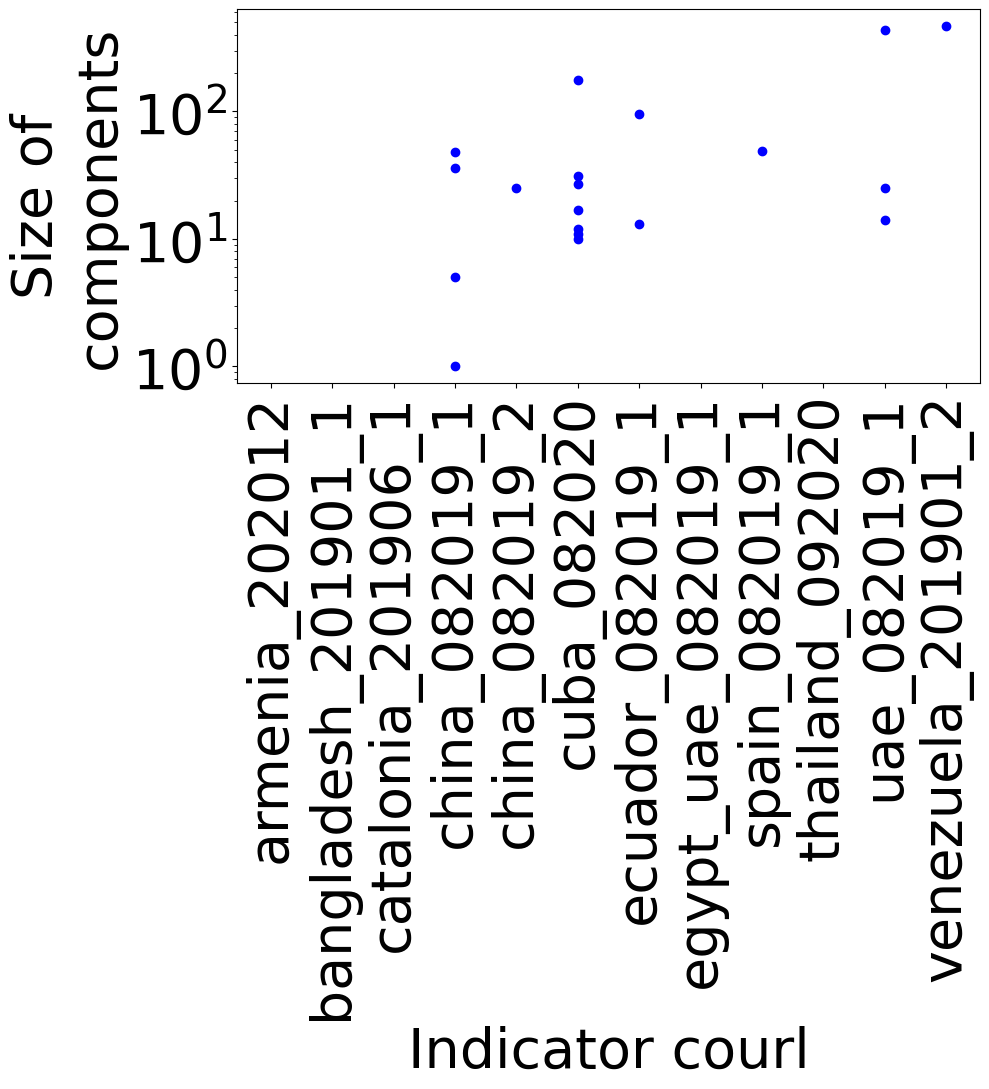

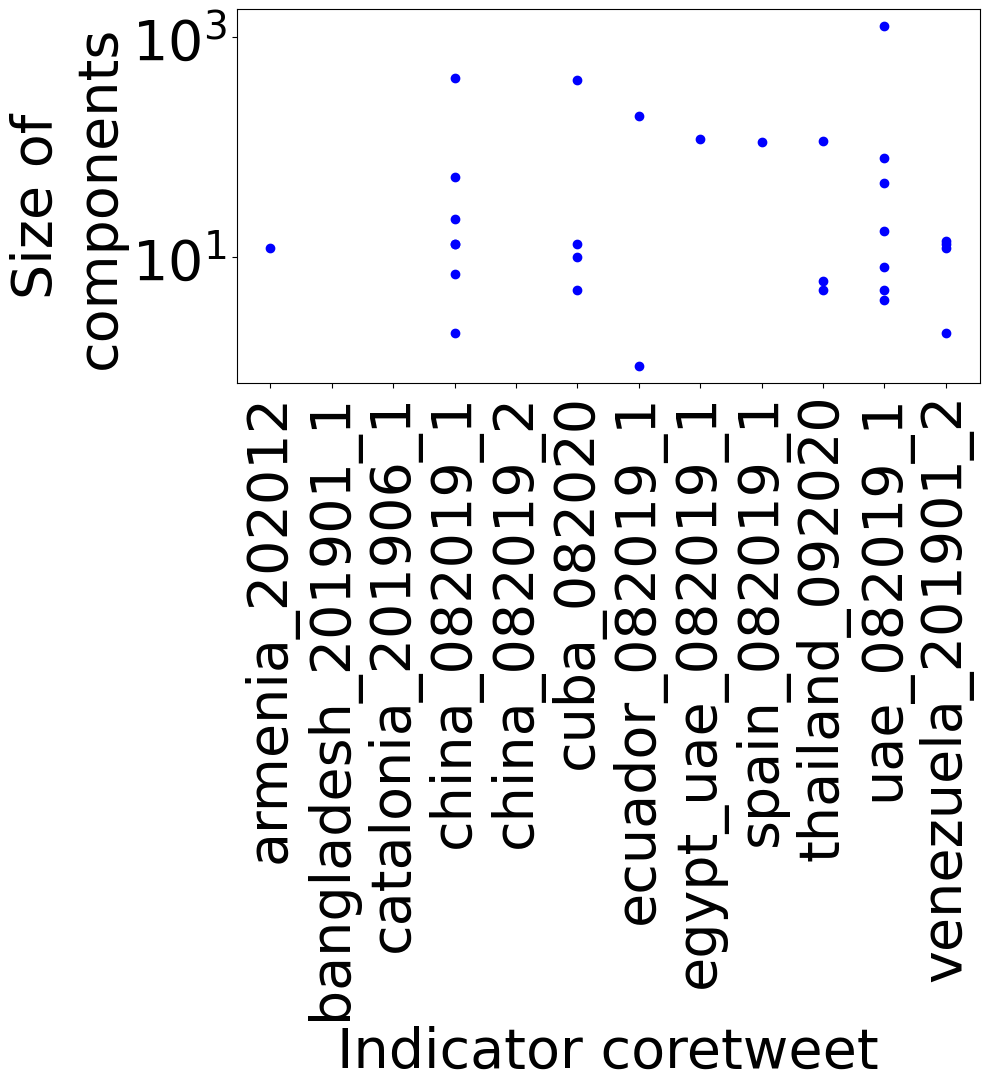

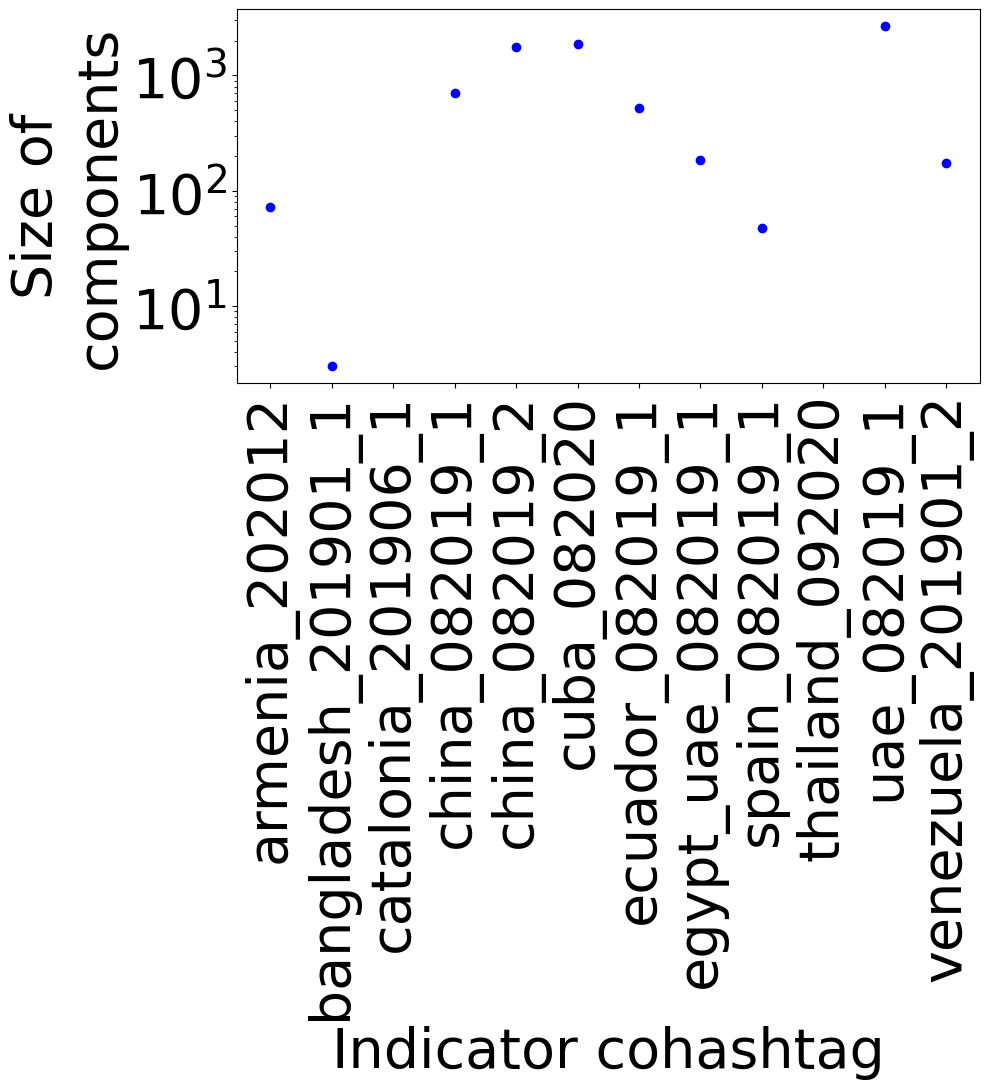

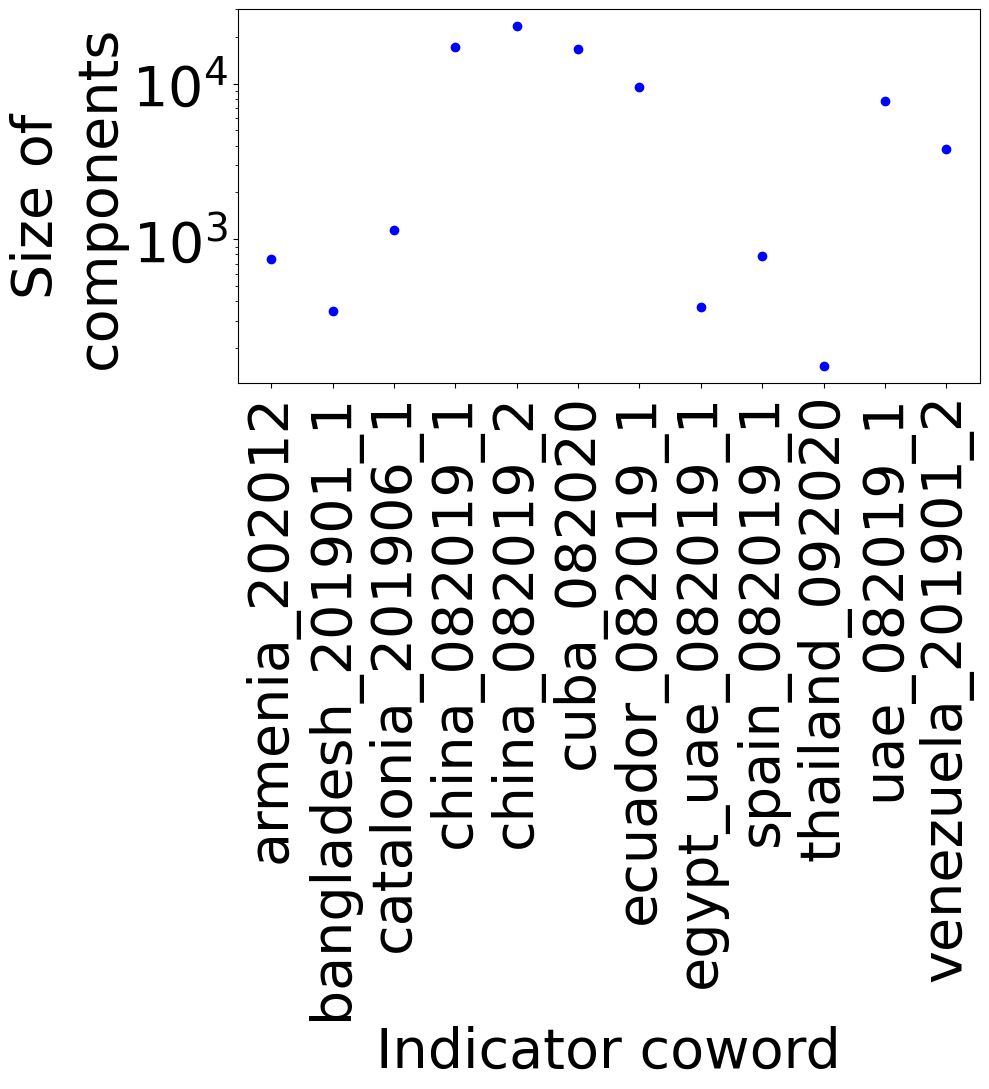

In [72]:

for x in df_expanded['indicator'].unique():
    df_x = df_expanded.loc[df_expanded['indicator'] == x]
    parameters =  {
            'fontsize': 40,
            'size': (10, 11),
            # 'bar': 'h',
            'x': df_x['campaign'],
            'y': df_x['size'],
            'xlabel': f'Indicator {x}', 
            'ylabel': 'Size of \ncomponents',
            # 'legend_location': '',
            'labelrotation': 90,
            'log_yscale': True,
            'title': '',
            'save': {
                'path': './plots',
                'filename': f'{x}_size_of_component.png'
            },
            'random_color': False
        }
    
    scatterplot(parameters)
    # break